# Imports

https://github.com/AminFiroozi/Trading-Algorithm-Project

In [330]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [331]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools import add_constant
import plotly.graph_objects as go
from statsmodels.regression.linear_model import OLS
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from datetime import datetime
from dateutil.relativedelta import relativedelta
from typing import Literal
import itertools

# Constants

## Control

In [332]:
FETCH_DATA = False
PLOT_SERIES = False
PLOT_RESULT = False
PLOT_SPREAD = False

## Market

In [333]:
RISK_FREE_RATE = 4.0 # percent

## Dataset

In [334]:
START_DATE = "2024-01-01"
END_DATE = "2026-01-01"

TOP_50 = ["BTC", "ETH", "XRP", "TRX", "LTC"]
SELECTED_TICKERS = ["BTC", "ETH", "XRP", "ENA", "LTC"]

## Mean-Reversion Bot

In [335]:
MR_MODE: Literal["explore", "exploit"] = "exploit"
TOTAL_COMBINATIONS = 100

## Martingale Bot

In [336]:
MAX_LEVELS = 10
INITIAL_ASSET = 1000
MARTINGALE_K = 2.0
TP_PERCENT = 2.5 / 100 # 2.5%
ANCHOR: Literal["Body", "Shadows"] = "Body"

## ADX Bot

In [442]:
THETA_ADX = 25
ADX_LOOKBACK = 14
SMA_SHORT_LB = 20
SMA_LONG_LB = 50
RSI_LOOKBACK = 14

RETURN = 'Return'
PLUS_DM = 'PDM'
MINUS_DM = 'MDM'
TR = 'TR'
ATR = 'ATR'
SMA_PLUS_DM = 'SMA+DM'
SMA_MINUS_DM = 'SMA-DM'
PLUS_DI = 'PDI'
MINUS_DI = 'MDI'
DX = 'DX'
ADX = 'ADX'
MARKET_STATE = 'MARKET_STATE'
SMA_SHORT = 'SMA_SHORT'
SMA_LONG = 'SMA_LONG'
SMA_SIGNAL = 'SMA_SIGNAL'
SMA_CROSSOVER = 'SMA_CROSSOVER'
GAIN = 'GAIN'
LOSS = 'LOSS'
AVERAGE_GAIN = 'AVERAGE_GAIN'
AVERAGE_LOSS = 'AVERAGE_LOSS'
RS = 'RS'
RSI = 'RSI'
RSI_SIGNAL = 'RSI_SIGNAL'
RSI_CROSSOVER = 'RSI_CROSSOVER'
FINAL_STRATEGY = 'FINAL_STRATEGY'
POSITION = 'POSITION'
STRATEGY_RETURN = 'strategy_return'
PORTFOLIO = 'portfolio'
MARKET_RETURN = 'MARKET_RETURN'

## Routes

In [443]:
TICKERS_DIR = "tickers"
PLOTS_DIR = "plots"

# Configuration

In [444]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)

# Functions

## Fetching data

In [445]:
def fetch_from_yfinance(ticker: str, route: str, start_date, end_date, fetch: bool=True):
    if fetch:
        s = ticker.upper().strip()
        yahoo_format = s if s.endswith("-USD") else f"{s}-USD"
        
        df1 = yf.download(
            tickers=yahoo_format,
            start=start_date,
            end=end_date,
            auto_adjust=False
        )
        df2 = yf.download(
            tickers=ticker,
            start=start_date,
            end=end_date,
            auto_adjust=False
        )
        
        if len(df1) > 0:
            df = df1
        if len(df2) > 0:
            df = df2
            
        df.to_csv(route)
        df = pd.read_csv(route, skiprows=[1, 2], header=0)
        df = df.rename(columns={'Price': 'Date'})
        df = df.set_index('Date')
        df.to_csv(route)
    else:
        df = pd.read_csv(route)
    return df

In [446]:
def filter_ticker(ticker, start: str, end: str):
    filename = os.path.join(TICKERS_DIR, f"{ticker}.csv")
    df_full = fetch_from_yfinance(ticker, filename, START_DATE, END_DATE, FETCH_DATA)
    df_full['Date'] = pd.to_datetime(df_full['Date'])
    start_ts = pd.to_datetime(start)
    end_ts = pd.to_datetime(end)

    mask = (df_full['Date'] >= start_ts) & (df_full['Date'] <= end_ts)
    df = df_full.loc[mask].copy()
    df = df.reset_index()
    df = df.drop(columns=['index'])
    return df

## Report

In [447]:
def max_drawdown(portfolio):
    portfolio_values = portfolio
    running_max = portfolio_values.cummax()
    drawdown = (portfolio_values - running_max) / running_max
    return drawdown.min() * 100

In [448]:
def sortino_ratio(strategy_returns, risk_free_rate: float = RISK_FREE_RATE, target_return=0):
    mean_return_annual = strategy_returns.mean() * 252
    
    downside_returns = strategy_returns[strategy_returns < target_return]
    
    volatility = downside_returns.std() * np.sqrt(252)
    
    if volatility == 0:
        SORTINO_RATIO = np.nan
    else:
        SORTINO_RATIO = (mean_return_annual - risk_free_rate) / volatility
    
    return SORTINO_RATIO

In [449]:
def sharpe_ratio(strategy_returns, risk_free_rate: float = RISK_FREE_RATE):
    mean_return = strategy_returns.mean() * 252

    volatility = strategy_returns.std() * np.sqrt(252)

    if volatility == 0:
        SHARPE_RATIO = np.nan
    else:
        SHARPE_RATIO = (mean_return - risk_free_rate) / volatility
        
    return SHARPE_RATIO

In [450]:
def time_underwater(df):
    price_series = df['Close']
    
    running_max = price_series.cummax()
    drawdown = (price_series - running_max) / running_max
    
    trough_idx = drawdown.idxmin()
    
    prices_before_trough = price_series.loc[:trough_idx]
    if len(prices_before_trough) == 0:
        return 0
    
    peak_idx = prices_before_trough.idxmax()
    peak_price = prices_before_trough.max()
    
    prices_after_trough = price_series.loc[trough_idx:]
    
    recovery_idx = None
    for idx in prices_after_trough.index:
        if price_series.loc[idx] > peak_price:
            recovery_idx = idx
            break
    
    if recovery_idx is None:
        return len(df) - peak_idx
    
    return recovery_idx - peak_idx

In [451]:
def profit_factor(trades):
    losses = 0
    profits = 0
    for trade in trades:
        if trade['pnl_pct'] >= 0:
            profits += trade['pnl_pct']
        else:
            losses -= trade['pnl_pct']
    # print(f"{profits} / {losses}")
    if losses == 0:
        return profits / 1
    return profits / losses

In [452]:
def grid_efficiency(trades):
    successful_resets = 0
    failure_resets = 0
    for trade in trades:
        if trade['pnl_pct'] >= 0:
            successful_resets += 1
        else:
            failure_resets += 1
    if failure_resets == 0:
        return successful_resets / 1
    return successful_resets / failure_resets

In [453]:
def calculate_performance_metrics(df, period_name="All"):
    max_dd = max_drawdown(df['portfolio'])
    sharpe = sharpe_ratio(df['strategy_return'])
    sortino = sortino_ratio(df['strategy_return'])
    total_return = ((df['portfolio'].iloc[-1] / df['portfolio'].iloc[0]) - 1) * 100
    underwater_time = time_underwater(df)
    
    print(f"\n{'='*60}")
    print(f"PERFORMANCE REPORT - {period_name}")
    print(f"{'='*60}")
    print(f"Period:           {df['Date'].iloc[0].date()} to {df['Date'].iloc[-1].date()}")
    print(f"Max Drawdown:     {max_dd:.2f}%")
    print(f"Sharpe Ratio:     {sharpe:+.3f}")
    print(f"Sortino Ratio:    {sortino:+.3f}")
    print(f"Total Return:     {total_return:+.3f}%")
    print(f"Underwater Time:  {underwater_time:+.3f}%")
    
    return {
        'period': period_name,
        'start_date': df['Date'].iloc[0],
        'end_date': df['Date'].iloc[-1],
        'max_drawdown': max_dd,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino,
        'total_return': total_return,
        'underwater_time': underwater_time
    }

In [454]:
def report_martingale(df, trades):
    martingale_df = df.copy()
    martingale_df['YearMonth'] = martingale_df['Date'].dt.to_period('M')
    months = martingale_df['YearMonth'].unique()
    months = sorted(months)
    for month in months:
        month_mask = martingale_df['YearMonth'] == month
        month_df = martingale_df[month_mask].copy()
        
        if len(month_df) > 1:
            calculate_performance_metrics(
                month_df, 
                f"MONTH {month.strftime('%Y-%m')}"
            )
    
    print('='*60)
    print("Total result:")
    print(f"Max Drawdown:    {max_drawdown(martingale_df['portfolio']):.2f}%")
    print(f"Sharpe Ratio:    {sharpe_ratio(martingale_df['strategy_return']):+.3f}")
    print(f"Sortino Ratio:   {sortino_ratio(martingale_df['strategy_return']):+.3f}")
    print(f"Strategy Return: {((martingale_df['portfolio'].iloc[-1] / martingale_df['portfolio'].iloc[0]) - 1) * 100:+.3f}%")
    print(f"Time Underwater: {time_underwater(martingale_df)}")
    print(f"Profit Factor:   {profit_factor(trades):.2f}")
    print(f"Grid Efficiency: {grid_efficiency(trades):.2f}")

In [455]:
def grid_efficiency(trades):
    successful_resets = 0
    failure_resets = 0
    for trade in trades:
        if trade['pnl_pct'] >= 0:
            successful_resets += 1
        else:
            failure_resets += 1
    if failure_resets == 0:
        return successful_resets / 1
    return successful_resets / failure_resets

## Stationary Tests

In [456]:
def adf_test(ticker, df, column='Close'):
    if df is None or df.empty or column not in df.columns:
        return {"Ticker": ticker, "Error": "Missing Data"}

    series = df[column].dropna()
    
    if len(series) < 20:
        return {"Ticker": ticker, "Error": f"Insufficient data points: {len(series)}"}

    result = adfuller(series, autolag='AIC')
    
    adf_output = {
        "Ticker": ticker,
        "ADF Statistic": round(result[0], 4),
        "p-value": round(float(result[1]), 4),
        "Stationary": result[1] < 0.05,
        "Lags Used": result[2],
        "Observations": result[3]
    }
    
    return adf_output

In [457]:
def hurst_exponent(series, q=2.0, max_lag=None, min_lag=2):
    series = np.asarray(series, dtype=float)
    n = len(series)

    if max_lag is None:
        max_lag = n // 4
    if max_lag <= min_lag:
        raise ValueError("max_lag must be > min_lag")

    # Lags
    lags = np.arange(min_lag, max_lag)

    # K_q values for each lag
    K = np.zeros_like(lags, dtype=float)

    for i, lag in enumerate(lags):
        diffs = np.abs(series[lag:] - series[:-lag])
        K[i] = np.mean(diffs ** q)

    # Fit log–log to estimate slope
    log_lags = np.log(lags)
    log_K = np.log(K)

    slope, _ = np.polyfit(log_lags, log_K, 1)

    Hurst = slope / q
    
    return Hurst

In [458]:
def half_life(series):
    series = series.dropna()
    
    if len(series) < 10:
        print("For half-life series must be longer than 10 values")
        return np.nan
    
    # Create lagged series
    price_lag = series.shift(1)
    price_diff = series - price_lag
    
    # Remove NaN values
    valid_data = pd.concat([price_lag, price_diff], axis=1).dropna()
    X = add_constant(valid_data.iloc[:, 0])
    y = valid_data.iloc[:, 1]
    
    # Perform OLS regression
    try:
        model = OLS(y, X)
        results = model.fit()
        
        beta = results.params.iloc[1]
        
        half_life = -np.log(2) / np.log(1 + beta) if (1 + beta) > 0 else np.nan
        
        return half_life
    except Exception as e:
        print(f"Error occured while calculating half life: ${e}")
        return np.nan

In [459]:
def johansen_test(df_combined, det_order=0, k_ar_diff=1):
    df_clean = df_combined.dropna()
    
    if df_clean.shape[1] < 2:
        print("Need at least 2 series for Johansen test.")
        return None

    result = coint_johansen(df_clean, det_order, k_ar_diff)
    
    traces = result.lr1
    cvts = result.cvt
    eigenvalues = result.eig
    
    summary = []
    for i in range(len(traces)):
        is_cointegrated = traces[i] > cvts[i, 1]
        summary.append({
            "Rank": i + 1,
            "Trace Stat": round(traces[i], 4),
            "CV 95%": round(cvts[i, 1], 4),
            "Significant": is_cointegrated
        })
    
    return pd.DataFrame(summary), result.evec[:, 0]

## Plotting

In [460]:
def store_series_plot(df, ticker: str, route: str = PLOTS_DIR):
    if not os.path.exists(route):
        os.makedirs(route)
        
    x_axis = df['Date'] if 'Date' in df.columns else df.index
        
    fig = go.Figure(data=[go.Candlestick(
        x=x_axis,
        open=df['Open'],
        high=df['High'],
        low=df['Low'],
        close=df['Close'],
    )])

    fig.update_layout(
        xaxis_title='Date',
        yaxis_title='Price',
        xaxis_rangeslider_visible=False,
        template='plotly_white',
        height=900,
        width=1600,
        showlegend=False
    )
    
    save_path = os.path.join(route, f"{ticker}.png")
    fig.write_image(save_path)

In [461]:
def plot_spread_candlestick(group, weights, dfs, folder="plots"):
    spread_df = pd.DataFrame(index=dfs[group[0]].index)
    
    spread_df['Close'] = sum(dfs[ticker]['Close'] * weights[i] for i, ticker in enumerate(group))
    spread_df['Open']  = sum(dfs[ticker]['Open'] * weights[i] for i, ticker in enumerate(group))
    
    spread_high = 0
    spread_low = 0
    for i, ticker in enumerate(group):
        if weights[i] >= 0:
            spread_high += dfs[ticker]['High'] * weights[i]
            spread_low  += dfs[ticker]['Low'] * weights[i]
        else:
            # If weight is negative, the asset's 'Low' contributes to the spread's 'High'
            spread_high += dfs[ticker]['Low'] * weights[i]
            spread_low  += dfs[ticker]['High'] * weights[i]
            
    spread_df['High'] = spread_high
    spread_df['Low']  = spread_low
    
    ticker_name = f"Spread_{'_'.join(group)}"
    store_series_plot(spread_df, ticker_name, folder)

In [462]:
def plot_overlay_normalized_candlesticks(group, dfs, ticker_name, folder=PLOTS_DIR):
    fig = go.Figure()

    # Distinct color pairs for up/down candles per ticker
    color_pairs = [
        {'inc': '#26a69a', 'dec': '#ef5350'}, # Teal / Red
        {'inc': '#2196f3', 'dec': '#f44336'}, # Blue / Bright Red
        {'inc': '#9c27b0', 'dec': '#e91e63'}, # Purple / Pink
        {'inc': '#ff9800', 'dec': '#795548'}, # Orange / Brown
        {'inc': '#4caf50', 'dec': '#ffeb3b'}  # Green / Yellow
    ]

    for i, ticker in enumerate(group):
        if ticker not in dfs:
            continue
            
        df = dfs[ticker].copy()
        
        # 1. Normalization: Divide all OHLC columns by the first Close price
        base_price = df['Close'].iloc[0]
        df_norm = df[['Open', 'High', 'Low', 'Close']] / base_price
        
        # 2. Select colors for this specific ticker
        colors = color_pairs[i % len(color_pairs)]
        
        # 3. Add the trace
        fig.add_trace(go.Candlestick(
            x=df.index,
            open=df_norm['Open'],
            high=df_norm['High'],
            low=df_norm['Low'],
            close=df_norm['Close'],
            name=f"{ticker} (Norm)",
            increasing_line_color=colors['inc'],
            decreasing_line_color=colors['dec'],
            increasing_fillcolor=colors['inc'],
            decreasing_fillcolor=colors['dec']
        ))

    # 4. Final Layout Adjustments
    fig.update_layout(
        title=f"Overlay Normalized Candlesticks: {', '.join(group)}",
        xaxis_title="Date",
        yaxis_title="Normalized Price (Base = 1.0)",
        xaxis_rangeslider_visible=False,
        template="plotly_white",
        height=600,
        width=1000,
        # This helps see the different candles if they overlap heavily
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    if not os.path.exists(folder):
        os.makedirs(folder)
        
    save_path = os.path.join(folder, f"Overlay_Normalized_{ticker_name}.png")
    fig.write_image(save_path)
    print(f"Overlay plot saved to {save_path}")

In [463]:
def plot_trades(df: pd.DataFrame, trades: list, ticker: str, mode: Literal["normal", "anti"] = "normal"):
    df_plot = df.copy()
    df_plot["Date"] = pd.to_datetime(df_plot["Date"])

    ema200 = df_plot["Close"].ewm(span=200, adjust=False).mean()

    fig = go.Figure()

    # (datetime.strptime(df_plot["Date"][0].date(), '%Y-%m-%d') - relativedelta(month=6)).strftime('%Y-%m-%d')
    train_df = filter_ticker(ticker=ticker, start="2023-07-01", end="2024-01-01")
    train_ema200 = train_df["Close"].ewm(span=200, adjust=False).mean()
    
    # ---- Candlesticks ----
    fig.add_trace(go.Candlestick(
        x=train_df["Date"],
        open=train_df["Open"],
        high=train_df["High"],
        low=train_df["Low"],
        close=train_df["Close"],
        name="Price"
    ))
    
    fig.add_trace(go.Candlestick(
        x=df_plot["Date"],
        open=df_plot["Open"],
        high=df_plot["High"],
        low=df_plot["Low"],
        close=df_plot["Close"],
        name="Price"
    ))
    
    # ---- EMA200 ----
    if mode == "anti":
        fig.add_trace(go.Scatter(
            x=train_df["Date"],
            y=train_ema200,
            mode="lines",
            line=dict(dash="dash", color="red"),
            name="EMA200"
        ))
        fig.add_trace(go.Scatter(
            x=df_plot["Date"],
            y=ema200,
            mode="lines",
            line=dict(dash="dash"),
            name="EMA200"
        ))
    
    # Equity curve
    fig.add_trace(go.Scatter(
        x=df_plot["Date"],
        y=df_plot['portfolio'] * (df['Close'].iloc[0] / df_plot['portfolio'].iloc[0]),
        mode="lines",
        opacity=0.5,
        name="Equity"
    ))

    # ---- Trades + Grid Levels ----    
    for idx, t in enumerate(trades):
        open_i = t["trade_open"]
        close_i = t["trade_close"]

        open_time = df_plot["Date"].iloc[open_i]
        close_time = df_plot["Date"].iloc[close_i]

        entry_price = t["open_price"]
        exit_price = t["exit_price"]
        avg_price = t["avg_price"]

        spacing = -t["spacing"] if mode == "normal" else t['spacing']
        levels_filled = t["levels_filled"]
        
        # ---- Average price line ----
        fig.add_trace(go.Scatter(
            x=[open_time, close_time],
            y=[avg_price, avg_price],
            mode="lines",
            line=dict(color="orange", width=2, dash="dash"),
            opacity=0.9,
            showlegend=False
        ))

        # ---- Trade line ----
        fig.add_trace(go.Scatter(
            x=[open_time, close_time],
            y=[avg_price, exit_price],
            mode="lines",
            line=dict(width=2, color="black"),
            opacity=1.0,
            showlegend=False
        ))
        
        # Exit line
        exit_price = avg_price * (1 + TP_PERCENT) if mode == "normal" else exit_price
        fig.add_trace(go.Scatter(
            x=[open_time, close_time],
            y=[exit_price, exit_price],
            mode="lines",
            line=dict(width=1, color="purple"),
            opacity=1.0,
            showlegend=False
        ))

        # ---- Grid levels ----
        levels_to_plot = levels_filled + 1 if mode == "normal" else levels_filled
        Range = range(min(levels_to_plot, MAX_LEVELS + 1)) if mode == "normal" else range(-1, min(levels_to_plot, MAX_LEVELS))
        for lvl in Range:
            level_price = entry_price * (1 + spacing) ** lvl

            fig.add_trace(go.Scatter(
                x=[open_time, close_time],
                y=[level_price, level_price],
                mode="lines",
                line=dict(
                    color="blue" if lvl == 0 else "red" if ((lvl == levels_filled and mode == "normal") or (lvl == MAX_LEVELS)) else "gray",
                    width=1,
                    dash="solid" if lvl == MAX_LEVELS else "dot"
                ),
                opacity=1.0 if lvl == MAX_LEVELS else 0.8,
                showlegend=False
            ))
            
            if (lvl == (levels_filled if mode == "normal" else levels_filled - 1)):
                fig.add_annotation(
                    x=open_time + (close_time - open_time) / 2,
                    y=level_price * (0.95 if mode == "normal" else 1.05),
                    text=f"#{idx}: {t['pnl_pct']:.4f}%",
                    showarrow=False,
                    textangle=90,
                    font=dict(size=12, color="black"),
                    bgcolor="rgba(255,255,255,0.7)"
                )

    fig.update_layout(
        title=f"{ticker} —{' Anti-' if mode == 'anti' else ' '}Martingale Grid Trades",
        xaxis_title="Date",
        yaxis_title="Price",
        template="plotly_white",
        xaxis_rangeslider_visible=False,
        xaxis=dict(type="date"),
        height=800,
        width=1400
    )

    fig.show()


In [464]:
def plot_portfolio(df):
    df_plot = df.copy()
    df_plot["Date"] = pd.to_datetime(df_plot["Date"])
    plt.figure(figsize=(14, 6))
    plt.plot(df_plot['Date'], df_plot['portfolio'], label='Strategy', linewidth=2, alpha=0.7)
    plt.axhline(y=INITIAL_ASSET, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Capital')
    plt.ylabel('Portfolio Value ($)', fontsize=12)
    plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
    plt.grid(True, alpha=0.3)
    plt.show()

# Process data

## Filter data

In [465]:
dfs = {}
if not os.path.exists(TICKERS_DIR):
    os.makedirs(TICKERS_DIR)
    print(f"Created directory: {TICKERS_DIR}")
tickers = TOP_50 if MR_MODE == "explore" else SELECTED_TICKERS
for ticker in tickers:
    filename = os.path.join(TICKERS_DIR, f"{ticker}.csv")
    try:
        dfs[ticker] = filter_ticker(ticker, START_DATE, END_DATE)
        if PLOT_SERIES:
            store_series_plot(dfs[ticker], ticker)
    except Exception as e:
        print(f"Failed to fetch {ticker}: {e}")

## Calculate parameters

In [466]:
summary_results = []

for ticker in tickers:
    filename = os.path.join(TICKERS_DIR, f"{ticker}.csv")
    try:
        df = filter_ticker(ticker, START_DATE, END_DATE)
        res = adf_test(ticker, df)
        res['hurst'] = hurst_exponent(df['Close'])
        res['half_life'] = str(round(half_life(df['Close']), 2))
        summary_results.append(res)
        
    except Exception as e:
        print(f"Failed {ticker}: {e}")
        
summary_df = pd.DataFrame(summary_results)
summary_df.head()

,Ticker,ADF Statistic,p-value,Stationary,Lags Used,Observations,hurst,half_life
0,BTC,-1.75,0.40,False,0,356,0.56,52.15
1,ETH,-1.60,0.48,False,1,361,0.57,39.64
2,XRP,-0.74,0.84,False,2,25,0.13,3.17
3,ENA,-2.18,0.21,False,0,638,0.49,45.03
4,LTC,-2.73,0.07,False,0,501,0.36,25.29


## Filter tickers with p-value $\le$ 0.05

In [467]:
stationary_df = summary_df[summary_df['p-value'] <= 0.05].copy()
stationary_df = stationary_df.sort_values(by='p-value')
half_life_df = stationary_df.sort_values(by='half_life')
print("Stationary tickers:", len(stationary_df))
half_life_df

Stationary tickers: 0


,Ticker,ADF Statistic,p-value,Stationary,Lags Used,Observations,hurst,half_life


## Mix series

In [468]:
found_combinations = []
non_stationary_tickers = summary_df[summary_df['p-value'] > 0.05]['Ticker'].tolist()

total_combinations = TOTAL_COMBINATIONS

for r in [4, 5]:
    if len(found_combinations) >= total_combinations: break
    
    potential_groups = list(itertools.combinations(non_stationary_tickers, r)) 

    for group in potential_groups:
        if len(found_combinations) >= total_combinations: break
        
        combined_data = pd.concat([dfs[t]['Close'] for t in group], axis=1).dropna()
        
        res = coint_johansen(combined_data, det_order=0, k_ar_diff=1)
        
        if res.lr1[0] > res.cvt[0, 1]: 
            weights = res.evec[:, 0] 
            found_combinations.append({
                'group': group,
                'weights': weights,
                'johansen_stat': res.lr1[0]
            })

## Get top combinations

In [469]:
results_with_hl = []

for item in found_combinations:
    group = item['group']
    weights = item['weights']
    
    spread_series = pd.Series(0, index=dfs[group[0]].index)
    for i, ticker in enumerate(group):
        spread_series += dfs[ticker]['Close'] * weights[i]
        
    if (spread_series < 0).all():
        # print(f"reversing sign of {group}")
        weights = [-w for w in weights]
        spread_series = pd.Series(0, index=dfs[group[0]].index)
        for i, ticker in enumerate(group):
            spread_series += dfs[ticker]['Close'] * weights[i]
    
    if (spread_series < 0).any():
        # print(f"skip {group} because of negative value")
        continue
    
    hl = half_life(spread_series)
    if hl is not np.nan and hl > 1:
        results_with_hl.append({
            'group': group,
            'half_life': hl,
            'spread_series': spread_series,
            'weights': weights
        })

top_combinations = sorted(results_with_hl, key=lambda x: x['half_life'])
for i in range(len(top_combinations)):
    print(f"{str(top_combinations[i]['group']):<40}: {top_combinations[i]['half_life']:.3f}")

('BTC', 'ETH', 'ENA', 'LTC')            : 7.089


## Plot spread series and normalized series

In [470]:
if PLOT_SPREAD:
    for comb in top_combinations:
        group = comb['group']
        weights = comb['weights']
        ticker_name = "_".join(group)
        plot_overlay_normalized_candlesticks(group, dfs, ticker_name)
        plot_spread_candlestick(group, weights, dfs)

# Strategies

## Mean-Reversion Bot

In [471]:
def calculate_mean_reversion_params(spread_df, hl_value):
    lookback = int(hl_value * (int(np.ceil(30 / hl_value)) if hl_value < 30 else 2))
    
    ema_range = spread_df['Close'].ewm(span=lookback, adjust=False).mean()
    std_spread = spread_df['Close'].rolling(window=lookback, min_periods=5).std()
    
    return lookback, ema_range, std_spread

In [472]:
strategy_results = []

for comb in top_combinations[:10]:
    group = comb['group']
    weights = comb['weights']
    hl = comb['half_life']
    
    spread_df = pd.DataFrame(index=dfs[group[0]].index)
    spread_df['Close'] = sum(dfs[ticker]['Close'] * weights[i] for i, ticker in enumerate(group))
    spread_df['Open']  = sum(dfs[ticker]['Open'] * weights[i] for i, ticker in enumerate(group))
    
    spread_df['Return'] = spread_df['Close'].pct_change(fill_method=None) * 100
    
    s_high, s_low = 0, 0
    for i, ticker in enumerate(group):
        if weights[i] >= 0:
            s_high += dfs[ticker]['High'] * weights[i]
            s_low  += dfs[ticker]['Low'] * weights[i]
        else:
            s_high += dfs[ticker]['Low'] * weights[i]
            s_low  += dfs[ticker]['High'] * weights[i]
    spread_df['High'], spread_df['Low'] = s_high, s_low
    
    lb, ema, std = calculate_mean_reversion_params(spread_df, hl)
    
    spread_df['std'] = std
    spread_df['ema'] = ema
    spread_df['Date'] = dfs[ticker]['Date']
    
    
    print(f"\nGroup: {'-'.join(group)}")
    print(f"Half-life: {hl:.2f} days")
    print(f"Calculated Lookback: {lb} days")
    print(f"Latest EMA (of Range): {ema.iloc[-1]:.4f}")
    print(f"Latest STD: {std.iloc[-1]:.4f}")
    
    strategy_results.append({
        'group': group,
        'spread_df': spread_df,
        'ema_range': ema,
        'std_spread': std,
        'lookback': lb
    })


Group: BTC-ETH-ENA-LTC
Half-life: 7.09 days
Calculated Lookback: 35 days
Latest EMA (of Range): 20.4288
Latest STD: 0.5443


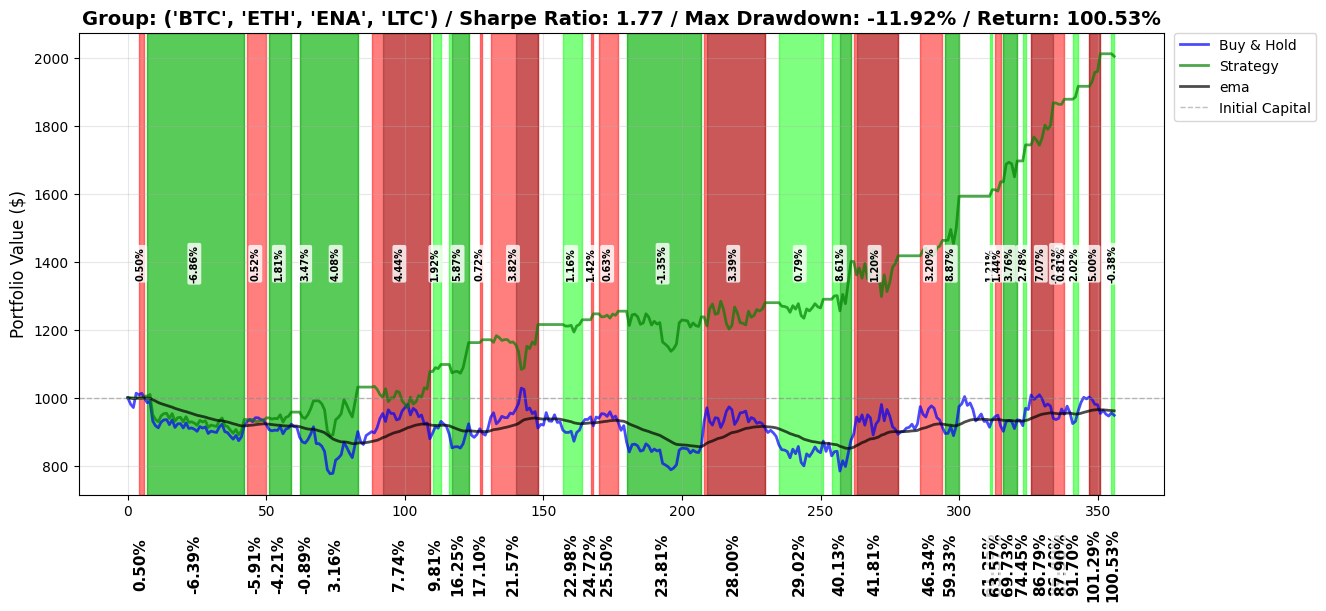

In [473]:
for result in strategy_results:
    # print(result['spread_df'])
    initial_asset = 1000
    df = result['spread_df']
    
    x = 0.01 # Safety ratio 
    result['spread_df']['short_signal1'] = np.where((df['High'] > df['ema'] + df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    result['spread_df']['short_signal2'] = np.where((df['High'] > df['ema'] + 2 * df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    
    result['spread_df']['long_signal1'] = np.where((df['Low'] < df['ema'] - df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    result['spread_df']['long_signal2'] = np.where((df['Low'] < df['ema'] - 2 * df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    
    result['spread_df']['above_ema'] = np.where(df['Close'] > df['ema'], 1, 0)
    result['spread_df']['below_ema'] = np.where(df['Close'] < df['ema'], 1, 0)
    
    result['spread_df']['ema_long_crossover'] = result['spread_df']['above_ema'].diff()
    result['spread_df']['ema_short_crossover'] = result['spread_df']['below_ema'].diff()
    
    result['spread_df']['short_crossover1'] = result['spread_df']['short_signal1'].diff()
    result['spread_df']['short_crossover2'] = result['spread_df']['short_signal2'].diff()
    
    result['spread_df']['long_crossover1'] = result['spread_df']['long_signal1'].diff()
    result['spread_df']['long_crossover2'] = result['spread_df']['long_signal2'].diff()
    
    current_position = 0
    positions = np.zeros(len(df))

    for i in range(len(df)):
        
        if result['spread_df']['below_ema'].iloc[i] == 1 and current_position < 0:
            current_position = 0
        elif result['spread_df']['above_ema'].iloc[i] == 1 and current_position > 0:
            current_position = 0
        elif result['spread_df']['short_crossover2'].iloc[i] == 1 and result['spread_df']['above_ema'].iloc[i] == 1:
            current_position = -2
        elif result['spread_df']['short_crossover1'].iloc[i] == 1 and current_position == 0:  
            current_position = -1
        elif result['spread_df']['long_crossover2'].iloc[i] == 1 and result['spread_df']['below_ema'].iloc[i] == 1:  
            current_position = +2
        elif result['spread_df']['long_crossover1'].iloc[i] == 1 and current_position == 0:  
            current_position = +1
        elif result['spread_df']['ema_long_crossover'].iloc[i] == 1 or result['spread_df']['ema_short_crossover'].iloc[i] == 1:
            current_position = 0
            
        positions[i] = current_position
        
    result['spread_df']['position'] = positions
    
    # ---------------------------------------------------------------------
    
    result['spread_df']['strategy_return'] = result['spread_df']['position'].shift(1) * result['spread_df']['Return'] / 2
    result['spread_df']['strategy_return'] = result['spread_df']['strategy_return'].fillna(0)
    
    portfolio_values = np.zeros(len(df) + 1)
    portfolio_values[0] = initial_asset

    for i in range(len(df)):
        portfolio_values[i + 1] = portfolio_values[i] * (1 + result['spread_df']['strategy_return'].iloc[i] / 100)

    result['spread_df']['portfolio'] = portfolio_values[1:]
    
    result['spread_df']['BNH'] = initial_asset * (1 + result['spread_df']['Return'] / 100).cumprod()
    result['spread_df'].loc[0, 'BNH'] = initial_asset
    
    # ------------------------------------------------------------------------------------------------------
    
    plt.figure(figsize=(14, 6))
    
    plt.plot(df.index, df['BNH'], label='Buy & Hold', linewidth=2, alpha=0.7, color='blue')
    plt.plot(df.index, df['portfolio'], label='Strategy', linewidth=2, alpha=0.7, color='green')
    # plt.plot(df.index, df['ema'], label='ema', linewidth=2, alpha=0.7, color='orange')
    plt.plot(df.index, df['ema'] * (initial_asset / df['ema'].iloc[0]), label='ema', linewidth=2, alpha=0.7, color='black')
    
    plt.axhline(y=initial_asset, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Capital')
    plt.ylabel('Portfolio Value ($)', fontsize=12)
    plt.title(f'Group: {result["group"]}', fontsize=14, fontweight='bold')
    # plt.legend(loc='best', fontsize=10)
    plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
    plt.grid(True, alpha=0.3)
    
    # ---------------------------------------------------------------------------------------------------------
    
    ax = plt.gca() # Get current axes
    long1pos = (df['position'] > 0) | (df['position'].shift(1) > 0)
    long2pos = (df['position'] == 2) | (df['position'].shift(1) == 2)
    short1pos = (df['position'] < 0) | (df['position'].shift(1) < 0)
    short2pos = (df['position'] == -2) | (df['position'].shift(1) == -2)
    plt.fill_between(df.index, 0, 1, where=(long1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#0F0')
    plt.fill_between(df.index, 0, 1, where=(short1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#F00')
    plt.fill_between(df.index, 0, 1, where=(long2pos), transform=ax.get_xaxis_transform(), alpha=0.3, color='#050')
    plt.fill_between(df.index, 0, 1, where=(short2pos), transform=ax.get_xaxis_transform(), alpha=0.3, color='#500')
    
    # ------------------------------------------------------------------------------------------------
    
    df = result['spread_df']
    df['trade_id'] = (np.sign(df['position']) != np.sign(df['position'].shift())).cumsum()
    
    active_df = df[df['position'] != 0].copy()

    if not active_df.empty:
        temp_df = active_df.reset_index()
        idx_col = temp_df.columns[0]
        
        # 3. Aggregate metadata
        trades = temp_df.groupby('trade_id').agg(
            pos_type=('position', 'first'),
            start_idx=(idx_col, 'first'),
            end_idx=(idx_col, 'last')
        )

        running_total_gain = 1
        
        for t_id, trade in trades.iterrows():
            # --- LAG FIX ---
            start_val = df.loc[trade['start_idx'], 'portfolio']
            try:
                end_val = df.loc[trade['end_idx'] + 1, 'portfolio']
            except:
                end_val = df.loc[trade['end_idx'], 'portfolio']

            actual_trade_return = (end_val / start_val - 1) * 100
            
            # Calculate Running Total (Total Gain from $initial_asset start)
            running_total_gain = (end_val / initial_asset - 1) * 100
            
            # Calculate horizontal center for the label
            mid_point = (trade['start_idx'] + trade['end_idx']) / 2
            
            label1 = f"{actual_trade_return:.2f}%"
            label2 = f"{running_total_gain:.2f}%"
            
            # 4. Placement
            ax.text(mid_point, 0.5, label1, 
                    transform=ax.get_xaxis_transform(),
                    fontweight='bold',
                    ha='center', va='center', 
                    fontsize=7, rotation=90,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
            
            ax.text(mid_point, -0.15, label2, 
                    transform=ax.get_xaxis_transform(),
                    fontweight='bold',
                    ha='center', va='center', 
                    fontsize=11, rotation=90,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
            
    
    
    columns_to_drop = [
        'short_crossover2', 'short_crossover1', 'long_crossover1', 'long_crossover2', 
        'short_signal1', 'short_signal2', 'long_signal1', 'long_signal2', 'above_ema', 'below_ema',
        'ema_long_crossover', 'ema_short_crossover', 
        'trade_id'
        ]
    
    result['spread_df'] = result['spread_df'].drop(columns=columns_to_drop)
        
    plt.title(f"Group: {result['group']} / Sharpe Ratio: {sharpe_ratio(result['spread_df']['strategy_return']):.2f} / Max Drawdown: {max_drawdown(result['spread_df']['portfolio']):.2f}% / Return: {(result['spread_df']['portfolio'].iloc[-1] / initial_asset - 1) * 100:.2f}%", fontsize=14, fontweight='bold')
    
# x = strategy_results[0]
# print(x['group'])

In [474]:
def no_bias_mean_reversion_bot(initial_asset: int = 1000, start_date: str = "2024-01-01", end_date: str | None = None):
    start_dt = pd.to_datetime(start_date)
    if end_date is None:    
        end_dt = start_dt + relativedelta(months=4)
        end_date = end_dt.date().strftime('%Y-%m-%d')
    
    deadline_dt = start_dt + relativedelta(months=1)
    
    train_start_date = start_dt - relativedelta(months=6)
    train_end_date = start_dt - relativedelta(days=1)
    
    # ------------------------------------------------------------------
    
    summary_results = []
    tickers = TOP_50 if MR_MODE == "explore" else SELECTED_TICKERS
    for ticker in tickers:
        try:
            df = filter_ticker(ticker, train_start_date.date().strftime('%Y-%m-%d'), train_end_date.date().strftime('%Y-%m-%d'))

            res = adf_test(ticker, df)
            res['hurst'] = hurst_exponent(df['Close'])
            res['half_life'] = half_life(df['Close'])
            res['df'] = df
            summary_results.append(res)

        except Exception as e:
            pass
            # print(f"Failed {ticker}: {e}")

    summary_df = pd.DataFrame(summary_results)
    stationary_df = summary_df[summary_df['p-value'] <= 0.05].copy()
    stationary_df = stationary_df.sort_values(by='p-value')
    found_combinations = []
    non_stationary_tickers = summary_df[summary_df['p-value'] > 0.05]['Ticker'].tolist()
    
    # --------------------------------------------------------------------------
    
    dfs = {item['Ticker']: item['df'] for item in summary_results}
    for r in [4, 5]:
        if len(found_combinations) >= TOTAL_COMBINATIONS: break
        
        potential_groups = list(itertools.combinations(non_stationary_tickers[:20], r)) 

        for group in potential_groups:
            if len(found_combinations) >= TOTAL_COMBINATIONS: break
            
            combined_data = pd.concat([dfs[t]['Close'] for t in group], axis=1).dropna()
            
            res = coint_johansen(combined_data, det_order=0, k_ar_diff=1)
            
            if res.lr1[0] > res.cvt[0, 1]: 
                weights = res.evec[:, 0] 
                found_combinations.append({
                    'group': group,
                    'weights': weights,
                    'johansen_stat': res.lr1[0]
                })
                
    # -------------------------------------------------------------------------------------
    
    results_with_hl = []
    for item in found_combinations:
        group = item['group']
        weights = item['weights']
        
        spread_series = pd.Series(0, index=dfs[group[0]].index)
        for i, ticker in enumerate(group):
            spread_series += dfs[ticker]['Close'] * weights[i]
            
        if (spread_series < 0).all():
            weights = [-w for w in weights]
            spread_series = pd.Series(0, index=dfs[group[0]].index)
            for i, ticker in enumerate(group):
                spread_series += dfs[ticker]['Close'] * weights[i]
        
        if (spread_series < 0).any():
            continue
        
        hl = half_life(spread_series)
        
        if hl is not np.nan and hl > 1:
            results_with_hl.append({
                'group': group,
                'half_life': hl,
                'spread_series': spread_series,
                'weights': weights
            })

    # ------------------------------------------------------------------------
    
    if len(results_with_hl) > 0:
        comb = sorted(results_with_hl, key=lambda x: x['half_life'])[0]
    else:
        return {}, start_dt + relativedelta(days=1)
    
    group = comb['group']
    weights = comb['weights']
    hl = comb['half_life']
    dfs = {ticker: filter_ticker(ticker, start_date, end_date) for ticker in group}
    
    spread_df = pd.DataFrame(index=dfs[group[0]].index)
    spread_df['Close'] = sum(dfs[ticker]['Close'] * weights[i] for i, ticker in enumerate(group))
    spread_df['Open']  = sum(dfs[ticker]['Open'] * weights[i] for i, ticker in enumerate(group))
    
    spread_df['Return'] = spread_df['Close'].pct_change(fill_method=None) * 100
    
    s_high, s_low = 0, 0
    for i, ticker in enumerate(group):
        if weights[i] >= 0:
            s_high += dfs[ticker]['High'] * weights[i]
            s_low  += dfs[ticker]['Low'] * weights[i]
        else:
            s_high += dfs[ticker]['Low'] * weights[i]
            s_low  += dfs[ticker]['High'] * weights[i]
    spread_df['High'], spread_df['Low'] = s_high, s_low
    
    lb, ema, std = calculate_mean_reversion_params(spread_df, hl)
    
    spread_df['std'] = std
    spread_df['ema'] = ema
    spread_df['Date'] = dfs[ticker]['Date']
    
    # ------------------------------------------------------
    
    result = {
        'group': group,
        'weights': weights,
        'spread_df': spread_df,
        'ema_range': ema,
        'std_spread': std,
        'lookback': lb
    }
    
    df = result['spread_df']
    
    result['spread_df']['coin'] = "*".join(group)
    result['spread_df']['weights'] = "*".join([str(weight) for weight in weights])
    x = 0.00 # Safety ratio 
    result['spread_df']['short_signal1'] = np.where((df['Close'] > df['ema'] + df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    result['spread_df']['short_signal2'] = np.where((df['Close'] > df['ema'] + 2 * df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    
    result['spread_df']['long_signal1'] = np.where((df['Close'] < df['ema'] - df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    result['spread_df']['long_signal2'] = np.where((df['Close'] < df['ema'] - 2 * df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    # result['spread_df']['short_signal1'] = np.where((df['High'] > df['ema'] + df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    # result['spread_df']['short_signal2'] = np.where((df['High'] > df['ema'] + 2 * df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    
    # result['spread_df']['long_signal1'] = np.where((df['Low'] < df['ema'] - df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    # result['spread_df']['long_signal2'] = np.where((df['Low'] < df['ema'] - 2 * df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    
    result['spread_df']['above_ema'] = np.where(df['Close'] > df['ema'], 1, 0)
    result['spread_df']['below_ema'] = np.where(df['Close'] < df['ema'], 1, 0)
    
    result['spread_df']['ema_long_crossover'] = result['spread_df']['above_ema'].diff()
    result['spread_df']['ema_short_crossover'] = result['spread_df']['below_ema'].diff()
    
    result['spread_df']['short_crossover1'] = result['spread_df']['short_signal1'].diff()
    result['spread_df']['short_crossover2'] = result['spread_df']['short_signal2'].diff()
    
    result['spread_df']['long_crossover1'] = result['spread_df']['long_signal1'].diff()
    result['spread_df']['long_crossover2'] = result['spread_df']['long_signal2'].diff()
    
    # --------------------------------------------------------------------------
    
    current_position = 0
    positions = np.zeros(len(df))

    for i in range(len(df)):
        if result['spread_df']['below_ema'].iloc[i] == 1 and current_position < 0:
            current_position = 0
        elif result['spread_df']['above_ema'].iloc[i] == 1 and current_position > 0:
            current_position = 0
        elif result['spread_df']['short_crossover2'].iloc[i] == 1 and result['spread_df']['above_ema'].iloc[i] == 1:
            current_position = -2
        elif result['spread_df']['short_crossover1'].iloc[i] == 1 and current_position == 0:  
            current_position = -1
        elif result['spread_df']['long_crossover2'].iloc[i] == 1 and result['spread_df']['below_ema'].iloc[i] == 1:  
            current_position = +2
        elif result['spread_df']['long_crossover1'].iloc[i] == 1 and current_position == 0:  
            current_position = +1
        elif result['spread_df']['ema_long_crossover'].iloc[i] == 1 or result['spread_df']['ema_short_crossover'].iloc[i] == 1:
            current_position = 0
            
        positions[i] = current_position
        
    result['spread_df']['position'] = positions
    
    closed_after_deadline = result['spread_df'][
        (result['spread_df']['Date'] >= deadline_dt) & 
        (result['spread_df']['position'] == 0)
    ]
    
    if not closed_after_deadline.empty:
        first_close_row = closed_after_deadline.iloc[0]
        new_start_date = first_close_row['Date']
    else:
        new_start_date = result['spread_df']['Date'].iloc[-1]
        
    
    mask = (result['spread_df']['Date'] <= new_start_date)
    result['spread_df'] = result['spread_df'].loc[mask].copy()
    
    # ----------------------------------------------------------------------------------------------
    
    df = result['spread_df']
    
    result['spread_df']['strategy_return'] = result['spread_df']['position'].shift(1) * result['spread_df']['Return'] / 2
    result['spread_df']['strategy_return'] = result['spread_df']['strategy_return'].fillna(0)
    
    portfolio_values = np.zeros(len(df) + 1)
    portfolio_values[0] = initial_asset

    for i in range(len(df)):
        portfolio_values[i + 1] = portfolio_values[i] * (1 + result['spread_df']['strategy_return'].iloc[i] / 100)

    result['spread_df']['portfolio'] = portfolio_values[1:]
    
    result['spread_df']['BNH'] = initial_asset * (1 + result['spread_df']['Return'] / 100).cumprod()
    result['spread_df'].loc[0, 'BNH'] = initial_asset
    
    # -------------------------------------------------------------
    
    plt.figure(figsize=(14, 6))
    
    plt.plot(df.index, df['BNH'], label='Buy & Hold', linewidth=2, alpha=0.7, color='blue')
    plt.plot(df.index, df['portfolio'], label='Strategy', linewidth=2, alpha=0.7, color='red')
    plt.plot(df.index, df['ema'] * (initial_asset / df['ema'].iloc[0]), label='ema', linewidth=2, alpha=0.7, color='black')
    
    plt.axhline(y=initial_asset, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Capital')
    plt.ylabel('Portfolio Value ($)', fontsize=12)
    plt.title(f'Group: {result["group"]}', fontsize=14, fontweight='bold')
    plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
    plt.grid(True, alpha=0.3)
    
    ax = plt.gca() # Get current axes
    long1pos = (df['position'] == 1) | (df['position'].shift(1) == 1)
    long2pos = (df['position'] == 2) | (df['position'].shift(1) == 2)
    short1pos = (df['position'] == -1) | (df['position'].shift(1) == -1)
    short2pos = (df['position'] == -2) | (df['position'].shift(1) == -2)
    plt.fill_between(df.index, 0, 1, where=(long1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#0F0')
    plt.fill_between(df.index, 0, 1, where=(short1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#F00')
    plt.fill_between(df.index, 0, 1, where=(long2pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#0A0')
    plt.fill_between(df.index, 0, 1, where=(short2pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#A00')
    
    df = result['spread_df']
    df['trade_id'] = (np.sign(df['position']) != np.sign(df['position'].shift())).cumsum()
    
    
    active_df = df[df['position'] != 0].copy()

    if not active_df.empty:
        temp_df = active_df.reset_index()
        idx_col = temp_df.columns[0]
        
        # 3. Aggregate metadata
        trades = temp_df.groupby('trade_id').agg(
            pos_type=('position', 'first'),
            start_idx=(idx_col, 'first'),
            end_idx=(idx_col, 'last')
        )

        running_total_gain = 1
        
        for t_id, trade in trades.iterrows():
            # --- LAG FIX ---
            start_val = df.loc[trade['start_idx'], 'portfolio']
            try:
                end_val = df.loc[trade['end_idx'] + 1, 'portfolio']
            except:
                end_val = df.loc[trade['end_idx'], 'portfolio']

            actual_trade_return = (end_val / start_val - 1) * 100
            
            # Calculate Running Total (Total Gain from $initial_asset start)
            running_total_gain = (end_val / initial_asset - 1) * 100
            
            # Calculate horizontal center for the label
            mid_point = (trade['start_idx'] + trade['end_idx']) / 2
            
            label1 = f"{actual_trade_return:.2f}%"
            label2 = f"{running_total_gain:.2f}%"
            
            # 4. Placement
            ax.text(mid_point, 0.5, label1, 
                    transform=ax.get_xaxis_transform(),
                    fontweight='bold',
                    ha='center', va='center', 
                    fontsize=7, rotation=90,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
            
            ax.text(mid_point, 0, label2, 
                    transform=ax.get_xaxis_transform(),
                    fontweight='bold',
                    ha='center', va='center', 
                    fontsize=11, rotation=90,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
            
    # plt.title(f"Group: {result['group']} / Sharpe Ratio: {sharpe_ratio(result['spread_df']['strategy_return']):.2f} / Max Drawdown: {max_drawdown(result['spread_df']['portfolio']):.2f}% / Return: {running_total_gain:.2f}%", fontsize=14, fontweight='bold')

    
    
    columns_to_drop = [
        'short_crossover2', 'short_crossover1', 'long_crossover1', 'long_crossover2', 
        'short_signal1', 'short_signal2', 'long_signal1', 'long_signal2', 'above_ema', 'below_ema',
        'ema_long_crossover', 'ema_short_crossover', 
        'trade_id'
        ]
    
    result['spread_df'] = result['spread_df'].drop(columns=columns_to_drop)
        

    plt.title(f"Group: {result['group']} / Sharpe Ratio: {sharpe_ratio(result['spread_df']['strategy_return']):.2f} / Max Drawdown: {max_drawdown(result['spread_df']['portfolio']):.2f}% / Return: {(result['spread_df']['portfolio'].iloc[-1] / initial_asset - 1) * 100:.2f}%", fontsize=14, fontweight='bold')
    plt.show()

    return result, new_start_date

# no_bias_mean_reversion_bot(INITIAL_ASSET, START_DATE, END_DATE)

C:\Users\afiro\AppData\Local\Temp\ipykernel_27384\3329346929.py:24: RankWarning:

Polyfit may be poorly conditioned

C:\Users\afiro\AppData\Local\Temp\ipykernel_27384\3329346929.py:24: RankWarning:

Polyfit may be poorly conditioned

C:\Users\afiro\AppData\Local\Temp\ipykernel_27384\3329346929.py:24: RankWarning:

Polyfit may be poorly conditioned

C:\Users\afiro\AppData\Local\Temp\ipykernel_27384\3329346929.py:24: RankWarning:

Polyfit may be poorly conditioned

C:\Users\afiro\AppData\Local\Temp\ipykernel_27384\3329346929.py:24: RankWarning:

Polyfit may be poorly conditioned

C:\Users\afiro\AppData\Local\Temp\ipykernel_27384\3329346929.py:24: RankWarning:

Polyfit may be poorly conditioned

C:\Users\afiro\AppData\Local\Temp\ipykernel_27384\3329346929.py:24: RankWarning:

Polyfit may be poorly conditioned

C:\Users\afiro\AppData\Local\Temp\ipykernel_27384\3329346929.py:24: RankWarning:

Polyfit may be poorly conditioned

C:\Users\afiro\AppData\Local\Temp\ipykernel_27384\3329346929.py:

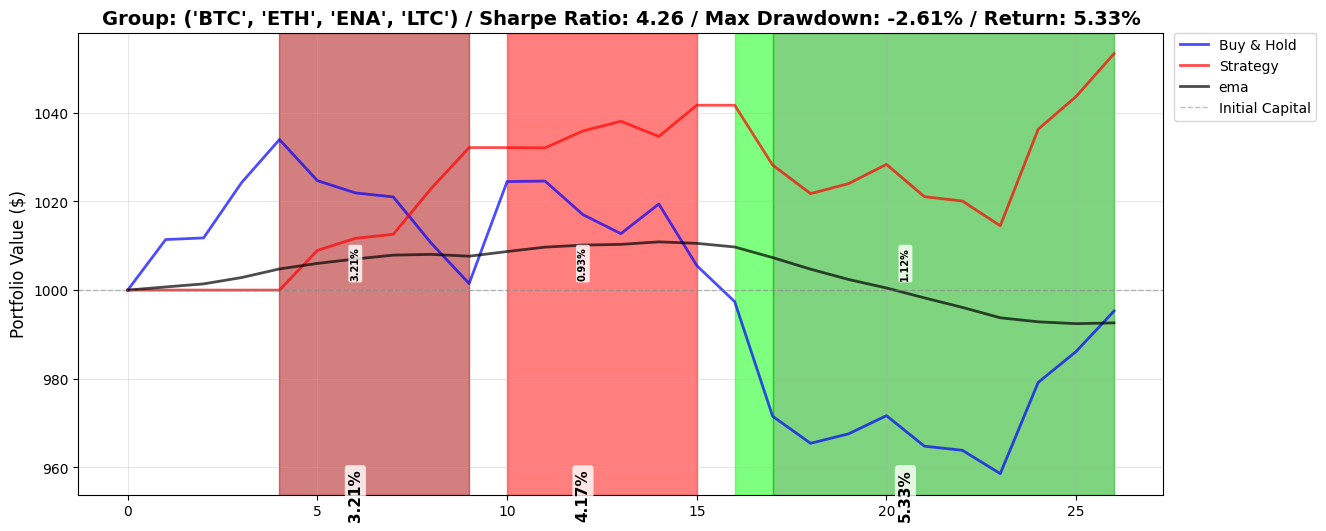

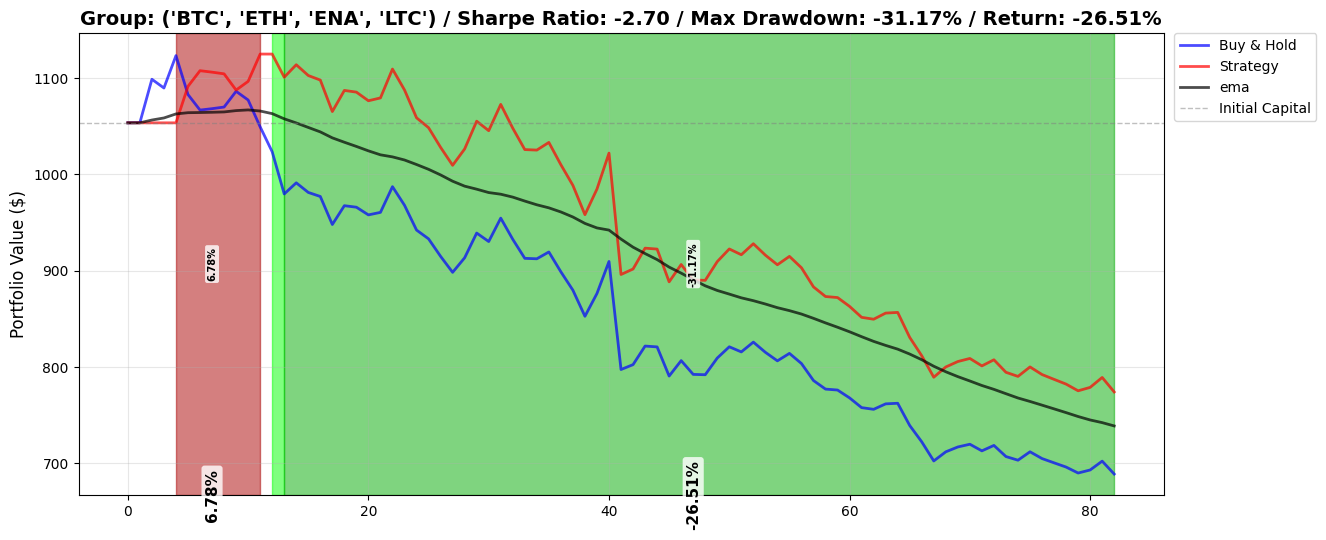

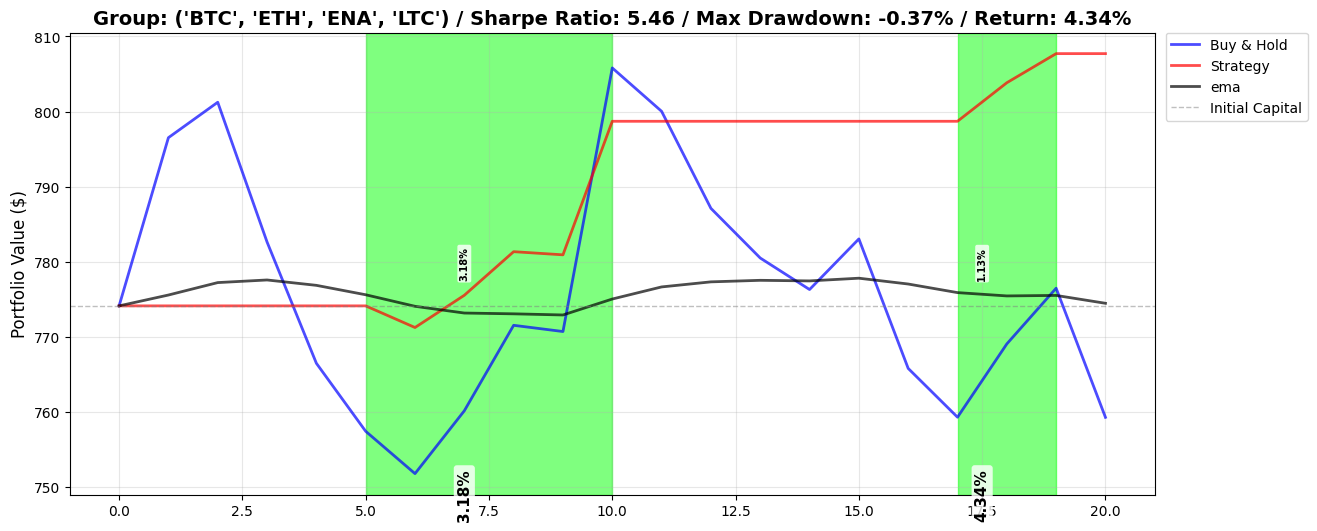

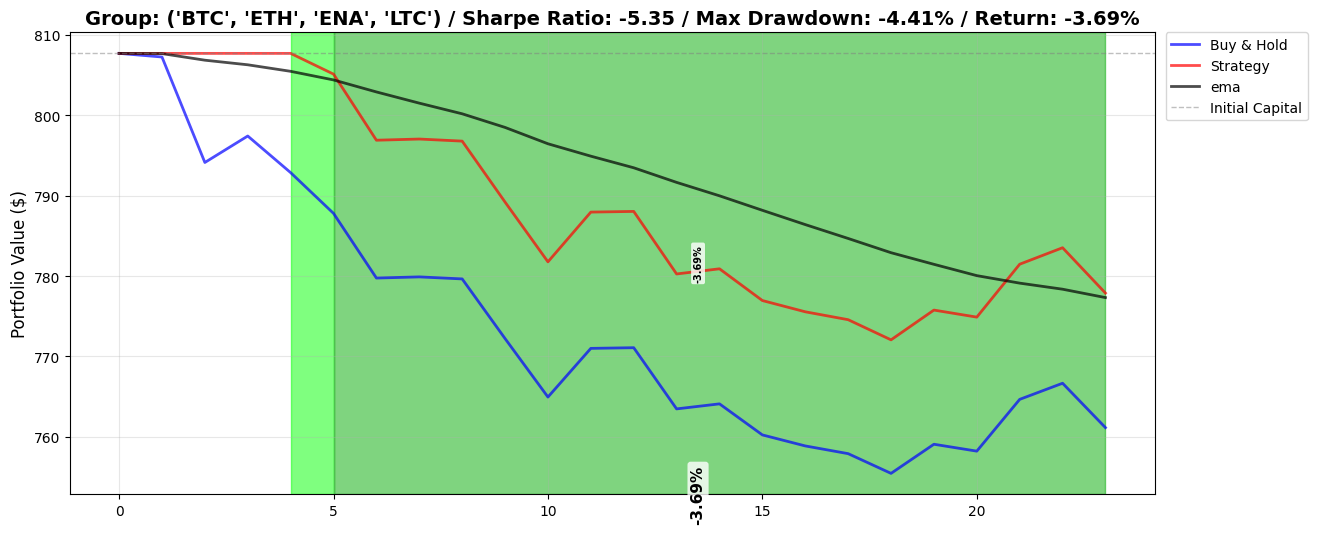

In [475]:
mean_reversion_monthly_results = []
starting_date = datetime(2024, 1, 1)
current_budget = 1000
while starting_date < datetime(2025, 12, 20):
    res, new_start = no_bias_mean_reversion_bot(current_budget, starting_date.strftime('%Y-%m-%d'))
    starting_date = pd.to_datetime(new_start)
    try:
        current_budget = res['spread_df']['portfolio'].iloc[-1]
        res['sharpe'] = sharpe_ratio(res['spread_df']['strategy_return'])
        res['max_drawdown'] = max_drawdown(res['spread_df']['portfolio'])
        mean_reversion_monthly_results.append(res)
    except:
        continue
    
final_df = pd.concat([mean_reversion_monthly_results[i]['spread_df'] for i in range(len(mean_reversion_monthly_results))], ignore_index=True)

In [476]:
Returns = list(map(lambda x: (x['spread_df']['portfolio'].iloc[-1] / x['spread_df']['portfolio'].iloc[0]) * 100 - 100, mean_reversion_monthly_results))
Portfolio = list(map(lambda x:  x['spread_df']['portfolio'].iloc[-1], mean_reversion_monthly_results))
start_dates = list(map(lambda x: (x['spread_df']['Date'].iloc[0]), mean_reversion_monthly_results))
end_dates = list(map(lambda x: (x['spread_df']['Date'].iloc[-1]), mean_reversion_monthly_results))

for i in range(len(Returns)):
    print(f"{Returns[i]:>5.2f}% in [{start_dates[i].date()} -> {end_dates[i].date()}] / Total: {(Portfolio[i] / 1000) * 100 - 100:>6.2f}%")

print(f"\nFinal portfolio value: {current_budget:.2f}$")
print(f"\nFinal Sharpe Ratio: {sharpe_ratio(final_df['strategy_return']):.2f}")
print(f"\nFinal Max Drawdown: {max_drawdown(final_df['portfolio']):.2f}%")
print(f"\nFinal Return: {(final_df['portfolio'].iloc[-1] / initial_asset - 1) * 100:.2f}%")

 5.33% in [2024-09-09 -> 2024-10-15] / Total:   5.33%
-26.51% in [2024-12-02 -> 2025-04-02] / Total: -22.59%
 4.34% in [2025-05-05 -> 2025-06-03] / Total: -19.23%
-3.69% in [2025-11-26 -> 2025-12-31] / Total: -22.21%

Final portfolio value: 777.88$

Final Sharpe Ratio: -1.61

Final Max Drawdown: -31.43%

Final Return: -22.21%


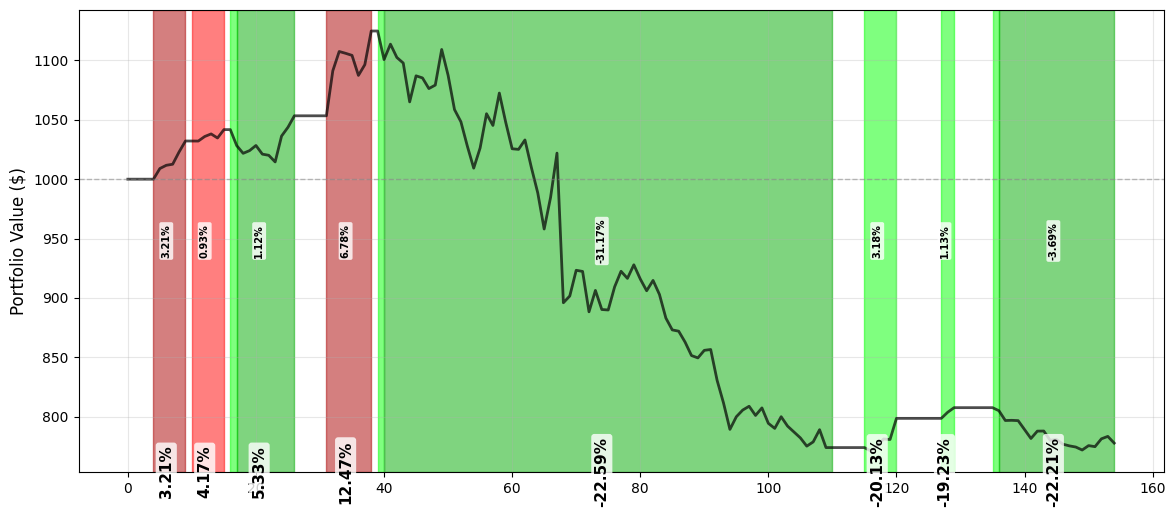

In [477]:
df = final_df
plt.figure(figsize=(14, 6))

plt.plot(df.index, df['portfolio'], label='equity', linewidth=2, alpha=0.7, color='black')

plt.axhline(y=initial_asset, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Capital')
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.grid(True, alpha=0.3)

ax = plt.gca() # Get current axes
long1pos = (df['position'] == 1) | (df['position'].shift(1) == 1)
long2pos = (df['position'] == 2) | (df['position'].shift(1) == 2)
short1pos = (df['position'] == -1) | (df['position'].shift(1) == -1)
short2pos = (df['position'] == -2) | (df['position'].shift(1) == -2)
plt.fill_between(df.index, 0, 1, where=(long1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#0F0')
plt.fill_between(df.index, 0, 1, where=(short1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#F00')
plt.fill_between(df.index, 0, 1, where=(long2pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#0A0')
plt.fill_between(df.index, 0, 1, where=(short2pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#A00')

df['trade_id'] = (np.sign(df['position']) != np.sign(df['position'].shift())).cumsum()

active_df = df[df['position'] != 0].copy()

if not active_df.empty:
    temp_df = active_df.reset_index()
    idx_col = temp_df.columns[0]
    
    # 3. Aggregate metadata
    trades = temp_df.groupby('trade_id').agg(
        pos_type=('position', 'first'),
        start_idx=(idx_col, 'first'),
        end_idx=(idx_col, 'last')
    )

    running_total_gain = 1
    
    for t_id, trade in trades.iterrows():
        # --- LAG FIX ---
        start_val = df.loc[trade['start_idx'], 'portfolio']
        try:
            end_val = df.loc[trade['end_idx'] + 1, 'portfolio']
        except:
            end_val = df.loc[trade['end_idx'], 'portfolio']

        actual_trade_return = (end_val / start_val - 1) * 100
        
        # Calculate Running Total (Total Gain from $initial_asset start)
        running_total_gain = (end_val / initial_asset - 1) * 100
        
        # Calculate horizontal center for the label
        mid_point = (trade['start_idx'] + trade['end_idx']) / 2
        
        label1 = f"{actual_trade_return:.2f}%"
        label2 = f"{running_total_gain:.2f}%"
        
        # 4. Placement
        ax.text(mid_point, 0.5, label1, 
                transform=ax.get_xaxis_transform(),
                fontweight='bold',
                ha='center', va='center', 
                fontsize=7, rotation=90,
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
        
        ax.text(mid_point, 0, label2, 
                transform=ax.get_xaxis_transform(),
                fontweight='bold',
                ha='center', va='center', 
                fontsize=11, rotation=90,
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
plt.show()

In [478]:
mean_reversion_bot = final_df
mean_reversion_bot['percent_invested'] = np.abs(mean_reversion_bot['position']) * 50
mean_reversion_bot

,Close,Open,Return,High,Low,std,ema,Date,coin,weights,position,strategy_return,portfolio,BNH,trade_id,percent_invested
0,43.42,43.29,NaN,43.68,42.86,NaN,43.42,2024-09-09,BTC*ETH*ENA*LTC,0.0820281744973264*0.2607503615283588*-7.48629...,0.00,0.00,1000.00,1000.00,1,0.00
1,43.92,43.50,1.14,44.07,43.43,NaN,43.46,2024-09-10,BTC*ETH*ENA*LTC,0.0820281744973264*0.2607503615283588*-7.48629...,0.00,0.00,1000.00,1011.40,1,0.00
2,43.94,43.52,0.04,44.10,42.98,NaN,43.49,2024-09-11,BTC*ETH*ENA*LTC,0.0820281744973264*0.2607503615283588*-7.48629...,0.00,0.00,1000.00,1011.77,1,0.00
3,44.48,44.15,1.23,44.57,43.85,NaN,43.55,2024-09-12,BTC*ETH*ENA*LTC,0.0820281744973264*0.2607503615283588*-7.48629...,0.00,0.00,1000.00,1024.23,1,0.00
4,44.90,44.58,0.95,45.08,44.35,0.57,43.63,2024-09-13,BTC*ETH*ENA*LTC,0.0820281744973264*0.2607503615283588*-7.48629...,-2.00,0.00,1000.00,1033.95,2,100.00
5,44.50,44.61,-0.90,44.80,44.24,0.53,43.69,2024-09-16,BTC*ETH*ENA*LTC,0.0820281744973264*0.2607503615283588*-7.48629...,-2.00,0.90,1008.96,1024.69,2,100.00
6,44.38,45.05,-0.27,45.40,44.06,0.49,43.73,2024-09-17,BTC*ETH*ENA*LTC,0.0820281744973264*0.2607503615283588*-7.48629...,-2.00,0.27,1011.68,1021.93,2,100.00
7,44.34,44.33,-0.09,45.02,43.89,0.45,43.77,2024-09-18,BTC*ETH*ENA*LTC,0.0820281744973264*0.2607503615283588*-7.48629...,-2.00,0.09,1012.58,1021.02,2,100.00
8,43.88,44.95,-1.02,45.15,43.52,0.44,43.77,2024-09-19,BTC*ETH*ENA*LTC,0.0820281744973264*0.2607503615283588*-7.48629...,-2.00,1.02,1022.93,1010.59,2,100.00
9,43.49,43.56,-0.90,44.02,43.19,0.47,43.76,2024-09-20,BTC*ETH*ENA*LTC,0.0820281744973264*0.2607503615283588*-7.48629...,0.00,0.90,1032.14,1001.48,3,0.00


# Martingale Bot

In [479]:
def atr(
    df: pd.DataFrame, 
    period: int = 14
):
    high = df["High"]
    low = df["Low"]
    close = df["Close"]

    tr1 = high - low
    tr2 = (high - close.shift()).abs()
    tr3 = (low - close.shift()).abs()

    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return tr.rolling(period).mean()

In [480]:
def above_ema200(df: pd.DataFrame, percentage: float = 70.0):
    ema200 = df['Close'].ewm(span=200, adjust=False).mean()
    above_ema = df['Close'] > ema200
    above_percentage = above_ema.mean() * 100
    return above_percentage > percentage

In [481]:
def strong_trend_range(
    df: pd.DataFrame, 
    atr_lookback: int = 14, 
    atr_period: int = 30
) -> bool:
    atr_df = atr(df, atr_lookback)
    recent_atr = atr_df.mean()
    average_price = df["Close"].mean()
    
    return (recent_atr / average_price) > 8 / 100

In [482]:
def grid_spacing(
    df: pd.DataFrame, 
    atr_period: int = 14, 
    multiplier: float = 1.0
) -> pd.Series: # in percent
    atr_df = atr(df, atr_period)
    return (atr_df * multiplier) / df['Close']

In [483]:
top_tickers = []
tickers = TOP_50 if MR_MODE == "explore" else SELECTED_TICKERS
for ticker in tickers:
    starting_train_date = (datetime(2025, 1, 1) - relativedelta(month=6)).strftime('%Y-%m-%d')
    df = filter_ticker(ticker=ticker, start="2024-07-01", end="2025-01-01")
    
    if df.empty:
        continue
    
    mode = []
    if above_ema200(df):
        # print(f"{ticker:<6} was above EMA200 with {above_ema200(df)}")
        # mode.append("trend")
        pass
        
    if strong_trend_range(df):
        # print(f"{ticker:<6} did have a strong trend or range")
        mode.append("range")
        
    if len(mode) > 0:
        df = filter_ticker(ticker=ticker, start=START_DATE, end=END_DATE)
        df['ATR'] = grid_spacing(df, atr_period=14, multiplier=1.0).fillna(0)
        df['Return'] = df['Close'].pct_change(fill_method=None) * 100
        if PLOT_RESULT:
            store_series_plot(df, ticker)

        top_tickers.append({
            "df": df,
            "symbol": ticker,
            "mode": mode,
        })

In [484]:
print(f"{len(top_tickers)} results were found")
top_tickers.sort(key=lambda ticker: ticker['df']['ATR'].median() , reverse=True)
print("\n".join(list(map(lambda ticker: f"{ticker['symbol']:>5}: {ticker['df']['ATR'].median() * 100:>5.2f}, {str(ticker['mode']):>5}", top_tickers))))

1 results were found
  ENA: 10.42, ['range']


In [485]:
def grid_levels(
    base_price: float,
    step_percent: float = 3 / 100, 
    levels: int = MAX_LEVELS,
    mode: Literal['normal', 'anti'] = 'normal'
) -> np.ndarray:
    if mode == 'normal':
        return base_price * (1 - step_percent) ** np.arange(levels + 1)
    else:
        return base_price * (1 + step_percent) ** np.arange(-1, levels + 1)

In [486]:
def martingale_sizing(
    base_volume: float, 
    levels: int = MAX_LEVELS, 
    multiplier: float = MARTINGALE_K
) -> np.ndarray:
    return base_volume * (multiplier ** np.arange(levels))

In [487]:
def average_price(
    base_price,
    base_volume,
    current_level,
    step_percent,
    mode: Literal['normal', 'anti'] = 'normal'
) -> float:
    prices = grid_levels(base_price, step_percent, current_level - 1, mode)[:-1]
    if mode == 'anti':
        prices = prices[1:]
    volumes = martingale_sizing(base_volume, current_level - 1)

    prices = np.array(prices, dtype=float)
    volumes = np.array(volumes, dtype=float)

    total_cost = np.sum(prices * volumes)
    total_size = np.sum(volumes)
    return float(total_cost / total_size) if total_size > 0 else base_price

In [488]:
def calculate_base_volume(
    base_price: float,
    asset: float = INITIAL_ASSET, 
    max_levels: int = MAX_LEVELS, 
    multiplier: float = MARTINGALE_K
) -> float:
    total_factor = (multiplier ** max_levels - 1) / (multiplier - 1)

    base_asset = asset / total_factor
    base_volume = base_asset / base_price

    return base_volume

In [489]:
def calculate_new_investment(
    remaining: float,
    current_level: int,
    max_levels: int = MAX_LEVELS, 
    multiplier: float = MARTINGALE_K
) -> float:
    levels_left = max_levels - current_level + 1
    return remaining * (multiplier - 1) / (multiplier**levels_left - 1)

In [490]:
def martingale_strategy():
    # for ticker in top_tickers[i:i+1]:
    ticker = top_tickers[0]
    # ticker = top_tickers[3]
    if "range" not in ticker["mode"]:
        print(f"{ticker['symbol']} isn't a range ticker")
        # continue
    print(ticker['symbol'])
    trades = []

    df = ticker['df']

    current_level = 0
    start_trade = 0

    strategy_return = []
    invested_asset = []
    levels = []
    remaining = []
    volume_asset = []
    exit_prices = []


    volume_filled = 0
    remaining_asset = INITIAL_ASSET

    terminated = False
    for time, row in df.iterrows():
        if row['ATR'] == 0 or terminated:
            levels.append(0)
            invested_asset.append(0)
            strategy_return.append(0)
            volume_asset.append(0)
            exit_prices.append(0)
            remaining.append(remaining_asset)
            continue
        
        price_high = row["Close" if ANCHOR == "Body" else "High"]
        price_low  = row["Close" if ANCHOR == "Body" else "Low"]
        
        if current_level == 0:
            start_trade = time
            current_level = 1
            new_investment = calculate_new_investment(remaining_asset, current_level)
            remaining_asset -= new_investment
            volume_filled += new_investment / df.iloc[start_trade]["Open"]
        
        step = df['ATR'].iloc[start_trade]
        base_price = df.iloc[start_trade]["Open"]
        base_volume = calculate_base_volume(base_price)
        
        grid_prices = grid_levels(base_price, step, MAX_LEVELS, 'normal')

        # ---- Safety Grids ----
        while (current_level < MAX_LEVELS and price_low < grid_prices[current_level - 1]):
            # print(f"Next level in {time} cause {price} < {grid_prices[current_level - 1]}")
            current_level += 1
            new_investment = calculate_new_investment(remaining_asset, current_level)
            remaining_asset -= new_investment
            volume_filled += new_investment / grid_prices[current_level - 1]

        avg_price = average_price(base_price, base_volume, current_level, df['ATR'].iloc[start_trade])
        
        # ---- Take Profit ----
        ROUND = 30
        
        filled_volumes = martingale_sizing(base_volume, current_level - 1)
        total_volume = sum(filled_volumes)

        reached_target_profit = (avg_price > 0 and price_high >= avg_price * (1 + TP_PERCENT)) or (avg_price == 0 and price_high >= base_price * (1 + TP_PERCENT))
        
        filled_all_levels = (price_low < grid_prices[-1])

        exit_price = max(float(avg_price * (1 + TP_PERCENT)), float(df['Low'].iloc[time]))
        pnl_usd = float((exit_price - avg_price) * total_volume)
        pnl_pct = float((pnl_usd / INITIAL_ASSET) * 100)

        end_price = exit_price if reached_target_profit else grid_prices[-1] if filled_all_levels else df['Close'].iloc[time]
        total_invested = end_price * volume_filled
        invested_asset.append(total_invested)
        levels.append(current_level)
        remaining.append(remaining_asset)
        volume_asset.append(volume_filled)
        exit_prices.append(exit_price)
        # ---- Take Profit ----
        if reached_target_profit:
            trades.append({
                "trade_open": start_trade,
                "trade_close": time,
                "open_price": round(float(df["Open"].iloc[start_trade]), ROUND),
                "exit_price": round(exit_price, ROUND),
                "avg_price": round(avg_price, ROUND),
                "pnl_usd": round(pnl_usd, 4),
                "pnl_pct": round(pnl_pct, 4),
                "spacing": round(float(df['ATR'].iloc[start_trade]), ROUND),
                "levels_filled": current_level - 1,
                "exit_type": "TP"
            })
            remaining_asset += volume_filled * exit_price
            volume_filled = 0
            current_level = 0
            continue

        # ---- Stop Loss (price below last grid) ----
        if filled_all_levels:
            trades.append({
                "trade_open": start_trade,
                "trade_close": time,
                "open_price": float(df["Open"].iloc[start_trade]),
                "exit_price": round(float(grid_prices[-1]), ROUND),
                "avg_price": round(avg_price, ROUND),
                "pnl_usd": round(pnl_usd, 4),
                "pnl_pct": round(pnl_pct, 4),
                "spacing": round(float(df['ATR'].iloc[start_trade]), ROUND),
                "levels_filled": current_level + 1,
                "exit_type": "SL"
            })
            remaining_asset += volume_filled * grid_prices[-1]
            volume_filled = 0
            terminated = True
        

    base_price = df.iloc[start_trade]["Open"]
    base_volume = calculate_base_volume(base_price)
    avg_price = average_price(base_price, base_volume, current_level - 1, df['ATR'].iloc[start_trade])

    filled_volumes = martingale_sizing(base_volume, current_level)
    total_volume = sum(filled_volumes)
    ROUND = 30

    pnl_usd = float((df["Close"].iloc[-1] - avg_price) * total_volume)
    pnl_pct = float((pnl_usd / INITIAL_ASSET) * 100)

    if current_level > 0 and len(trades) > 0 and trades[-1]['exit_type'] != "SL":
        trades.append({
            "trade_open": start_trade,
            "trade_close": len(df) - 1,
            "open_price": df.iloc[start_trade]["Open"],
            "exit_price": df["Close"].iloc[-1],
            "avg_price": round(avg_price, ROUND),
            "pnl_usd": round(pnl_usd, ROUND),
            "pnl_pct": round(pnl_pct, ROUND),
            "spacing": df['ATR'].iloc[start_trade],
            "levels_filled": current_level,
            "exit_type": "SL" if (df["Close"].iloc[-1] < avg_price) else "TP"
        })
        
    df['remaining'] = remaining
    df['invested'] = invested_asset
    df['portfolio'] = df['remaining'] + df['invested']
    df['percent_invested'] = df['invested'] / df['portfolio']
    df['strategy_return'] = df['portfolio'].pct_change(fill_method=None) * 100
    df['volume_asset'] = volume_asset
    df['level'] = levels
    df['exit_price'] = exit_prices
    df['coin'] = ticker['symbol']
    report_martingale(df, trades)
    # plot_portfolio(df)
    plot_trades(
        df=df,
        trades=trades,
        ticker=ticker['symbol']
    )
    return df
# df.tail(100)
        
martingale_bot = martingale_strategy()

ENA

PERFORMANCE REPORT - MONTH 2024-04
Period:           2024-04-02 to 2024-04-30
Max Drawdown:     -0.10%
Sharpe Ratio:     -6.310
Sortino Ratio:    -6.915
Total Return:     +0.050%
Underwater Time:  +21.000%

PERFORMANCE REPORT - MONTH 2024-05
Period:           2024-05-01 to 2024-05-31
Max Drawdown:     -0.22%
Sharpe Ratio:     -5.381
Sortino Ratio:    -11.697
Total Return:     +0.073%
Underwater Time:  +19.000%

PERFORMANCE REPORT - MONTH 2024-06
Period:           2024-06-01 to 2024-06-30
Max Drawdown:     -6.27%
Sharpe Ratio:     +0.951
Sortino Ratio:    +1.533
Total Return:     +3.487%
Underwater Time:  -32.000%

PERFORMANCE REPORT - MONTH 2024-07
Period:           2024-07-01 to 2024-07-31
Max Drawdown:     -14.52%
Sharpe Ratio:     -4.559
Sortino Ratio:    -3.448
Total Return:     -13.437%
Underwater Time:  -60.000%

PERFORMANCE REPORT - MONTH 2024-08
Period:           2024-08-01 to 2024-08-31
Max Drawdown:     0.00%
Sharpe Ratio:     +nan
Sortino Ratio:    +nan
Total Return:   

# ADX Bot

In [491]:
def apply_dm_logic(row):
    dmp = row['DMP']
    dmn = row['DMN']
    
    dm_plus = dmp if dmp > 0 else 0
    dm_minus = -dmn if dmn < 0 else 0 
    
    if dm_plus > 0 and dm_minus > 0:
        if dm_plus > dm_minus:
            dm_minus = 0
        else:
            dm_plus = 0
            
    return pd.Series({'DM_Plus': dm_plus, 'DM_Minus': dm_minus})

In [492]:
def report_adx(df):
    print("Total result:")
    print(f"Max Drawdown:    {max_drawdown(df['portfolio']):.2f}%")
    print(f"Sharpe Ratio:    {sharpe_ratio(df['strategy_return']):+.3f}")
    print(f"Sortino Ratio:   {sortino_ratio(df['strategy_return']):+.3f}")
    print(f"Strategy Return: {((df['portfolio'].iloc[-1] / df['portfolio'].iloc[0]) - 1) * 100:+.3f}%")

In [493]:
adx_dfs = {}
for ticker in tickers:
    df = filter_ticker(ticker=ticker, start=START_DATE, end=END_DATE)
    df['DMP'] = df['High'].diff()
    df['DMN'] = df['Low'].diff()
    dm_results = df.apply(apply_dm_logic, axis=1)
    df[PLUS_DM] = dm_results['DM_Plus']
    df[MINUS_DM] = dm_results['DM_Minus']
    df['High_Low'] = df['High'] - df['Low']
    df['High_PrevClose'] = abs(df['High'] - df['Close'].shift(1))
    df['Low_PrevClose'] = abs(df['Low'] - df['Close'].shift(1))
    df[TR] = df[['High_Low', 'High_PrevClose', 'Low_PrevClose']].max(axis=1)
    df[ATR] = df[TR].rolling(window=ADX_LOOKBACK).mean()
    df[SMA_PLUS_DM] = df[PLUS_DM].rolling(window=ADX_LOOKBACK).mean()
    df[SMA_MINUS_DM] = df[MINUS_DM].rolling(window=ADX_LOOKBACK).mean()
    df[PLUS_DI] = df[SMA_PLUS_DM] / df[ATR] * 100
    df[MINUS_DI] = df[SMA_MINUS_DM] / df[ATR] * 100
    df[DX] = abs(df[PLUS_DI] - df[MINUS_DI])/abs(df[PLUS_DI] + df[MINUS_DI]) * 100
    df[ADX] = df[DX].rolling(window=ADX_LOOKBACK).mean()
    df[MARKET_STATE] = np.where(df[ADX] > THETA_ADX, 'trending', 'sideways')
    df[SMA_SHORT] = df['Close'].rolling(window=SMA_SHORT_LB).mean()
    df[SMA_LONG] = df['Close'].rolling(window=SMA_LONG_LB).mean()
    df[SMA_SIGNAL] = np.where(df[SMA_SHORT] > df[SMA_LONG], 1, 0)
    df[SMA_CROSSOVER] = df[SMA_SIGNAL].diff()
    df[RETURN] = df['Close'].pct_change() * 100
    df[GAIN] = np.maximum(df[RETURN], 0) * 100
    df[LOSS] = np.maximum(-df[RETURN], 0) * 100
    df[AVERAGE_GAIN] = df[GAIN].rolling(window=RSI_LOOKBACK).mean()
    df[AVERAGE_LOSS] = df[LOSS].rolling(window=RSI_LOOKBACK).mean()
    df[RS] = df[AVERAGE_GAIN] / df[AVERAGE_LOSS]
    df[RSI] = 100 - 100 / (1 + df[RS])
    conditions = [df[RSI] > 70, df[RSI] < 30]
    choices =    [      -1      ,       +1      ]
    df[RSI_SIGNAL] = np.select(conditions, choices, default=0)
    df['RSI-Crossover-temp'] = df[RSI_SIGNAL].diff()
    df[RSI_CROSSOVER] = np.where(df[RSI_SIGNAL] != 0, df['RSI-Crossover-temp'], 0)
    df[FINAL_STRATEGY] = np.where(df[MARKET_STATE] == 'trending', df[SMA_CROSSOVER], df[RSI_CROSSOVER])
    signals = df[FINAL_STRATEGY].values
    returns = df[RETURN].values
    current_position = 0
    positions = np.zeros(len(signals))
    for i in range(len(signals)):
        if signals[i] == 1: 
            current_position = 1
        elif signals[i] == -1:
            current_position = -1
        positions[i] = current_position

    df[POSITION] = positions
    df[STRATEGY_RETURN] = df[POSITION] * df[RETURN]
    df[STRATEGY_RETURN] = df[STRATEGY_RETURN].fillna(0)
    portfolio_values = np.zeros(len(df) + 1)
    portfolio_values[0] = INITIAL_ASSET

    for i in range(len(df)):
        portfolio_values[i + 1] = portfolio_values[i] * (1 + df[STRATEGY_RETURN].iloc[i] / 100)

    df[PORTFOLIO] = portfolio_values[1:]
    df[MARKET_RETURN] = INITIAL_ASSET * (1 + df[RETURN] / 100).cumprod()
    df.loc[0, MARKET_RETURN] = INITIAL_ASSET
    print(f"Reporting {ticker}")
    report_adx(df)
 
    
    df = df.drop(columns=[
        'DMP', 'DMN',
        'High_Low', 'High_PrevClose', 'Low_PrevClose',
        'RSI-Crossover-temp',
    ])
    adx_dfs[ticker] = df

Reporting BTC
Total result:
Max Drawdown:    -45.99%
Sharpe Ratio:    -0.617
Sortino Ratio:   -0.874
Strategy Return: -35.687%
Reporting ETH
Total result:
Max Drawdown:    -50.36%
Sharpe Ratio:    -0.083
Sortino Ratio:   -0.118
Strategy Return: -28.936%
Reporting XRP
Total result:
Max Drawdown:    0.00%
Sharpe Ratio:    +nan
Sortino Ratio:   +nan
Strategy Return: +0.000%
Reporting ENA
Total result:
Max Drawdown:    -85.80%
Sharpe Ratio:    +0.307
Sortino Ratio:   +0.459
Strategy Return: -47.820%
Reporting LTC
Total result:
Max Drawdown:    -28.94%
Sharpe Ratio:    -0.769
Sortino Ratio:   -1.127
Strategy Return: -19.436%
